In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle

In [11]:
#Parámetros del problema
m=500 #Número de usuarios
n=100 #Número máximo de médicos
dt=10 #Tiempo en minutos
K=144 #Número de intervalos de Tiempo
velocidad=30 #En unidades de km/hora
r=np.random.uniform(low=0, high=30, size=(m,2)) #Posiciones de los usuarios
H=12 #Horas de un turno de un médico
beta=int(H*60/dt) #Numero máximo de turnos seguidos por un médico, 
Cmed=25000*H
distancias = cdist(r, r)
delta=distancias/velocidad*60 #Matriz de distancias en minutos
delta=np.ceil(delta/dt) #Matriz de distancias en intervalos de tiempo
delta={(i+1,j+1):delta[i,j] for i in range(0,m) for j in range(0,m)}
costo=distancias*600 #Costo de $600 por km de recorrido
costo={(i+1,j+1):costo[i,j] for i in range(0,m) for j in range(0,m)}
#Agregaremos los nodos de origen S y destino T, por ahora con valores 0 en tiempo y costo
for i in range(1,m+1):
    delta['S',i]=0
    delta[i,'T']=0
    costo['S',i]=0
    costo[i,'T']=0
#Generación de parámetros de servicio de los pacientes
a={i:np.random.randint(low=1, high=K-10) for i in range(1,m+1)} #Tiempo de llegada de los usuarios
b={}
c={}
for i in range(1,m+1):
    ventana=np.random.randint(low=4, high=20) #Duración de la ventana de servicio
    ventana=min(144-a[i]-1, ventana)
    b[i]=a[i]+ventana+1
    duracion=np.random.randint(low=1, high=b[i]-a[i])
    c[i]=duracion

#Parámetros auxiliares para construir las ecuaciones
alfa={}
tau={i:[] for i in range(1,m+1)}
for i in range(1,m+1):
    for k in range(1, K+1):
        if(k>=a[i] and k<=b[i]-c[i]+1):
            alfa[i,k]=1
            tau[i].append(k)
        else:
            alfa[i,k]=0
Mt=K

In [6]:
# Solución heurística del problema
def heuristicBase(n, mostrar=True):
    pacientes = sorted(range(1, m + 1), key=lambda i: (tau[i][0], len(tau[i]), b[i], i))
    medicos = {j: {'pacientes': [], 'inicio_turno': None, 'fin_turno': None, 'ultimo': None} for j in range(1, n + 1)}
    asignacion = {}

    for i in pacientes:
        asignado = False
        for j in range(1, n + 1):
            info = medicos[j]
            if info['ultimo'] is None:
                inicio_minimo = tau[i][0]
                inicio_turno = None
                anterior = 'S'
            else:
                anterior = info['ultimo']
                inicio_minimo = int(info['fin_turno'] + delta[anterior, i])
                inicio_turno = info['inicio_turno']

            inicio_asignado = None
            for k in tau[i]:
                if k < inicio_minimo:
                    continue
                if inicio_turno is not None and k + c[i] > inicio_turno + beta:
                    continue
                inicio_asignado = int(k)
                break

            if inicio_asignado is None:
                continue

            fin_servicio = int(inicio_asignado + c[i])
            if info['inicio_turno'] is None:
                info['inicio_turno'] = inicio_asignado
            info['fin_turno'] = fin_servicio
            info['ultimo'] = i
            info['pacientes'].append(i)
            asignacion[i] = {
                'medico': j,
                'inicio': inicio_asignado,
                'fin': fin_servicio,
                'anterior': anterior
            }
            asignado = True
            break

        if not asignado:
            resultado = {
                'factible': False,
                'costo': None,
                'medicos_activos': sum(1 for info in medicos.values() if info['pacientes']),
                'asignacion': asignacion,
                'orden_pacientes': pacientes,
                'paciente_no_asignado': i,
                'medicos': medicos
            }
            print(f'Factible: {resultado["factible"]}')
            print(f'No fue posible asignar el paciente {i} con {n} medico(s).')
            return resultado

    costo_total = 0.0
    medicos_activos = 0
    for j in range(1, n + 1):
        ruta = medicos[j]['pacientes']
        if not ruta:
            continue
        medicos_activos += 1
        costo_total += Cmed
        anterior = 'S'
        for paciente in ruta:
            costo_total += float(costo[anterior, paciente])
            anterior = paciente
        costo_total += float(costo[anterior, 'T'])

    resultado = {
        'factible': True,
        'costo': costo_total,
        'medicos_activos': medicos_activos,
        'asignacion': asignacion,
        'orden_pacientes': pacientes,
        'medicos': medicos
    }

    print(f'Factible: {resultado["factible"]}')
    print(f'Costo: {resultado["costo"]:.2f}')
    print(f'Medicos activos: {resultado["medicos_activos"]}')

    if mostrar:
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % cmap.N) for i in range(m + 1)]
        plt.figure(figsize=(20, 10))
        ax = plt.gca()
        lw = 0.4

        for j in range(0, n + 1):
            plt.plot([0, K], [j, j], '-k', linewidth=lw)
            if j < n:
                plt.text(-4, j, str(j + 1))
        for k in range(0, K + 1):
            plt.plot([k, k], [0, n], '-k', linewidth=lw)
            if k < K and (k + 1) % 5 == 0:
                plt.text(k, -0.5, str(k + 1), fontsize=10, rotation=90)

        for j in range(1, n + 1):
            info = medicos[j]
            if not info['pacientes']:
                continue
            inicio = info['inicio_turno']
            fin_turno = min(inicio + beta, K + 1)
            for k in range(inicio, fin_turno):
                rect = Rectangle(
                    (k - 1, j - 1),
                    1,
                    1,
                    facecolor='lightgray',
                    edgecolor='black',
                    linewidth=lw
                )
                ax.add_patch(rect)

        for i, info_asig in asignacion.items():
            j = info_asig['medico']
            k = info_asig['inicio']
            for paso in range(c[i]):
                rect = Rectangle(
                    (k - 1 + paso, j - 1),
                    1,
                    1,
                    facecolor=colors[i - 1],
                    edgecolor=colors[i - 1],
                    linewidth=1
                )
                ax.add_patch(rect)
            centro = k - 1 + c[i] / 2
            plt.text(centro, j - 1, f'Us {i}', ha='center', va='center', fontsize=8)

        plt.xlim(0, K)
        plt.ylim(0, max(1, n))
        plt.title(f'Solucion heuristica con {n} medico(s)')
        plt.tight_layout()
        plt.show()

    return resultado



In [7]:
def heuristic(n, orden_pacientes, mostrar=True):

    # ---------------------------------------------------------
    # Validación del cromosoma / orden de pacientes
    # ---------------------------------------------------------
    pacientes_esperados = set(range(1, m + 1))

    if len(orden_pacientes) != m:
        raise ValueError(
            f"orden_pacientes debe contener exactamente {m} pacientes."
        )

    if set(orden_pacientes) != pacientes_esperados:
        raise ValueError(
            "orden_pacientes debe ser una permutación de "
            f"los pacientes {list(range(1, m + 1))}."
        )

    # Se respeta exactamente el orden recibido.
    pacientes = list(orden_pacientes)

    # ---------------------------------------------------------
    # Inicialización
    # ---------------------------------------------------------
    medicos = {
        j: {
            'pacientes': [],
            'inicio_turno': None,
            'fin_turno': None,
            'ultimo': None
        }
        for j in range(1, n + 1)
    }

    asignacion = {}

    # ---------------------------------------------------------
    # Construcción voraz siguiendo el orden recibido
    # ---------------------------------------------------------
    for i in pacientes:

        asignado = False

        for j in range(1, n + 1):

            info = medicos[j]

            # Médico todavía inactivo
            if info['ultimo'] is None:
                inicio_minimo = tau[i][0]
                inicio_turno = None
                anterior = 'S'

            # Médico ya activo
            else:
                anterior = info['ultimo']

                inicio_minimo = int(
                    info['fin_turno'] + delta[anterior, i]
                )

                inicio_turno = info['inicio_turno']

            # Buscar el inicio factible más temprano
            inicio_asignado = None

            for k in tau[i]:

                if k < inicio_minimo:
                    continue

                if (
                    inicio_turno is not None
                    and k + c[i] > inicio_turno + beta
                ):
                    continue

                inicio_asignado = int(k)
                break

            # Este médico no puede atender al paciente
            if inicio_asignado is None:
                continue

            # -------------------------------------------------
            # Fijar asignación
            # -------------------------------------------------
            fin_servicio = int(inicio_asignado + c[i])

            if info['inicio_turno'] is None:
                info['inicio_turno'] = inicio_asignado

            info['fin_turno'] = fin_servicio
            info['ultimo'] = i
            info['pacientes'].append(i)

            asignacion[i] = {
                'medico': j,
                'inicio': inicio_asignado,
                'fin': fin_servicio,
                'anterior': anterior
            }

            asignado = True
            break

        # -----------------------------------------------------
        # No fue posible insertar el paciente
        # -----------------------------------------------------
        if not asignado:

            resultado = {
                'factible': False,
                'costo': None,
                'medicos_activos': sum(
                    1 for info in medicos.values()
                    if info['pacientes']
                ),
                'asignacion': asignacion,
                'orden_pacientes': pacientes,
                'paciente_no_asignado': i,
                'medicos': medicos
            }

            if mostrar:
                print(f'Factible: {resultado["factible"]}')
                print(
                    f'No fue posible asignar el paciente {i} '
                    f'con {n} medico(s).'
                )

            return resultado

    # ---------------------------------------------------------
    # Cálculo del costo
    # ---------------------------------------------------------
    costo_total = 0.0
    medicos_activos = 0

    for j in range(1, n + 1):

        ruta = medicos[j]['pacientes']

        if not ruta:
            continue

        medicos_activos += 1
        costo_total += Cmed

        anterior = 'S'

        for paciente in ruta:
            costo_total += float(costo[anterior, paciente])
            anterior = paciente

        costo_total += float(costo[anterior, 'T'])

    # ---------------------------------------------------------
    # Resultado
    # ---------------------------------------------------------
    resultado = {
        'factible': True,
        'costo': costo_total,
        'medicos_activos': medicos_activos,
        'asignacion': asignacion,
        'orden_pacientes': pacientes,
        'medicos': medicos
    }

    if mostrar:
        print(f'Factible: {resultado["factible"]}')
        print(f'Costo: {resultado["costo"]:.2f}')
        print(f'Medicos activos: {resultado["medicos_activos"]}')

    return resultado

100%|██████████| 200/200 [00:09<00:00, 21.90it/s]


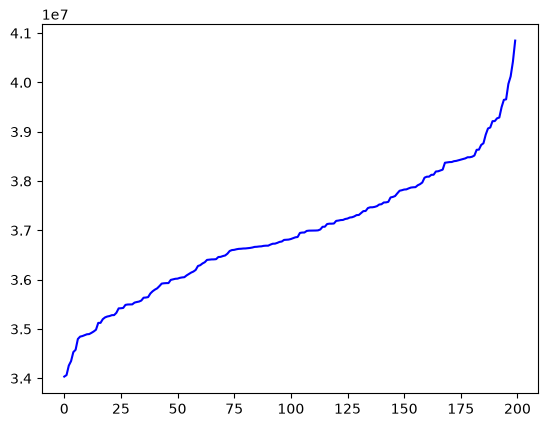

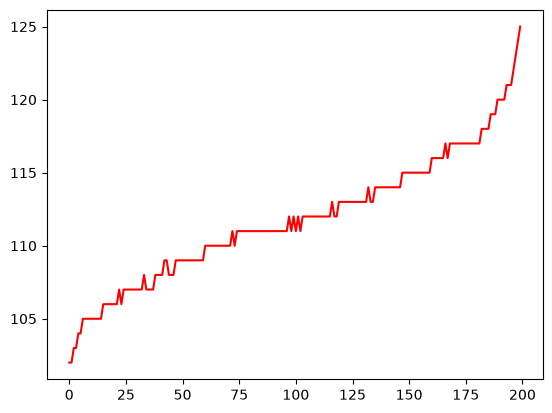

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from tqdm import tqdm
class solucion:
  def __init__(self, n, m, cromosoma=[]):
    self.n=n
    self.m=m
    if(len(cromosoma)==0):
      self.X=np.random.permutation(range(1,m+1))
      #print(self.X, len(self.X))
    else:
      self.X=cromosoma.copy()
    self.Z, self.N=self.f() #Z es la variable que representa el valor de fitnness de la solución

  def f(self): #Función de Fitness
    sln=heuristic(self.n, self.X, mostrar=False)
    costo=sln['costo']
    num_medicos=sln['medicos_activos']
    return costo, num_medicos
  
P=[]
for _ in tqdm(range(200)):
  P.append(solucion(n=500, m=500, cromosoma=[]))
Z=[pi.Z for pi in P]
plt.plot(sorted([z for z in Z]), '-b')
ind=np.argsort([z for z in Z])
nMed=np.array([pi.N for pi in P])[ind]
plt.figure()
plt.plot(nMed, '-r')

In [25]:
# Operadores genéticos
def prunning(P, Np): #Poda
  Z=np.array([xi.Z for xi in P])
  ind=np.argsort(-Z)[:Np]
  P=[P[i] for i in range(len(P)) if i not in ind]
  return P

def mutacion(P, Nm, num): #num representa cuantos genes modificamos
  #Vamos a elegir para mutar, a las soluciones más malas. Conservando las mejores con menor probabilidad de mutación
  Pr=np.ones(len(P))/len(P)
  ind=np.random.choice(size=Nm, a=range(len(Pr)), p=Pr) #ind representa los seres de la población a modificar
  for i in ind:
    #print(P[i].X)
    for a,b in np.random.choice(size=(num,2), a=range(len(P[i].X))):
      P[i].X[a], P[i].X[b]=P[i].X[b], P[i].X[a]
    P[i].Z, P[i].N=P[i].f()
  return P

def reproduccion(P, Nc):
  ind=np.random.randint(size=(Nc,2), low=0, high=len(P))
  L=int(len(P[0].X)/2)
  for i,j in ind:
    Xi=P[i].X.copy()
    Xj=P[j].X.copy()
    #Se deben tomar los L primeros de Xi, pero luego retirarlos de Xj y lo que quede pegarlo
    a=Xi[:L]
    b=[x for x in Xj if x not in a]
    P.append(solucion(P[0].n, P[0].m, np.concatenate([a,b])))
  return P



Mejor Z original:  33447229.50074843
Mejor Z Luego de prunning:  33447229.50074843
Mejor Z luego de mutación:  33447229.50074843
Mejor Z luego de reproducción:  33447229.50074843


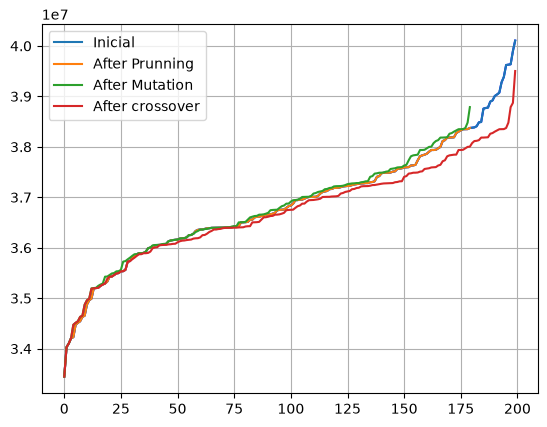

In [26]:
M=200
Np=20
Nm=20
Nc=20
num=20
P=[solucion(n=500, m=500, cromosoma=[]) for _ in range(M)]
Z=[pi.Z for pi in P]
plt.plot(sorted([z for z in Z]), '-b')

Z=[xi.Z for xi in P]
print('Mejor Z original: ', min(Z))
plt.plot(sorted(Z), label='Inicial')
P=prunning(P, Np)
Z=[xi.Z for xi in P]
print('Mejor Z Luego de prunning: ', min(Z))
plt.plot(sorted(Z), label='After Prunning')
P=mutacion(P, Nm, num)
Z=[xi.Z for xi in P]
print('Mejor Z luego de mutación: ', min(Z))
plt.plot(sorted(Z), label='After Mutation')
P=reproduccion(P, Nc)
Z=[xi.Z for xi in P]
print('Mejor Z luego de reproducción: ', min(Z))
plt.plot(sorted(Z), label='After crossover')
plt.legend()

plt.grid()

Mejor solucion inicial:  33238154.398828577
Iteración:  498 , Mejor valor:  31674915.249651168

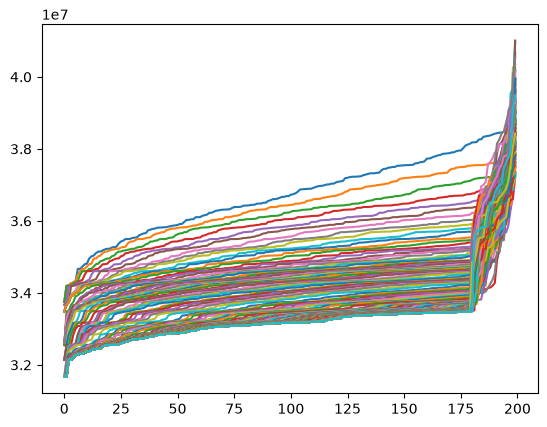

In [22]:
from tqdm import tqdm
P=[solucion(n=500, m=500, cromosoma=[]) for i in range(M)]

NumIter=500
dv=2
print('Mejor solucion inicial: ',min(Z))
best=solucion(n=500, m=500, cromosoma=P[np.argmin(Z)].X)
error=[best.Z]
mejor=solucion(n=500, m=500, cromosoma=P[np.argmin(Z)].X)
#print('Mejor solución al incio: ', best.Z)

for i in range(NumIter):
  P=prunning(P, Np)
  P=mutacion(P, Nm,50)
  P=reproduccion(P, Nc)
  Z=[xi.Z for xi in P]
  mejor=solucion(n=500, m=500, cromosoma=P[np.argmin(Z)].X)
  if(i%dv==0):
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
    plt.plot(sorted([xi.Z for xi in P]))
  if(mejor.Z<best.Z):
    best=solucion(n=500, m=500, cromosoma=mejor.X)
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
  error.append(best.Z)

  if(best.Z==0):
    print('\nSolución encontrada')
    break


Factible: True
Costo: 26335545.34
Medicos activos: 78


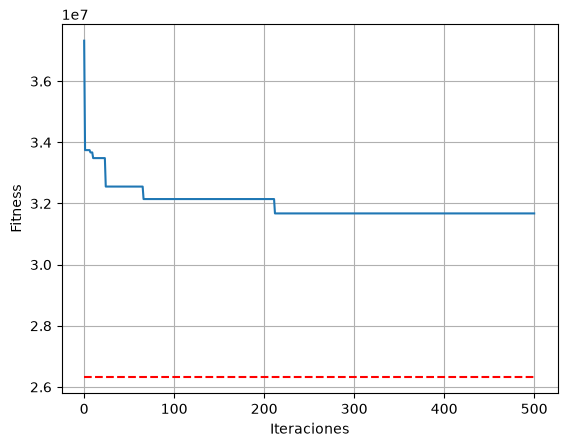

In [24]:
solBase=heuristicBase(n=500, mostrar=False)['costo']
plt.figure()
plt.plot(error)
plt.xlabel('Iteraciones')
plt.ylabel('Fitness')
plt.grid()
plt.hlines(y=solBase, color='r', xmin=0, xmax=len(error), linestyle='--', label='Solución Base')